<a href="https://colab.research.google.com/github/anushkahalder16/anushkahalder/blob/main/biofynix2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  s

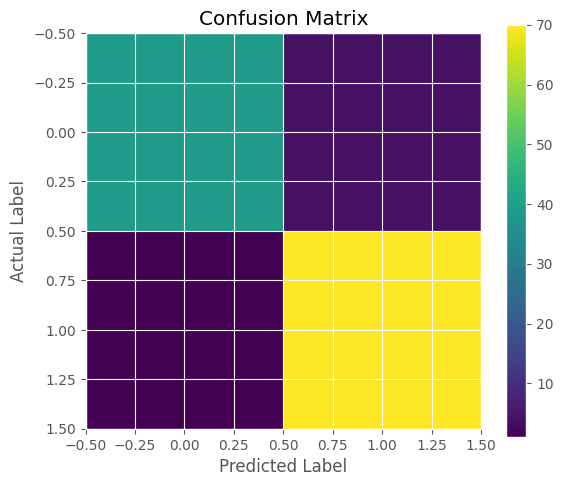

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



,Actual Class,Predicted Class
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


In [1]:
# ============================================
# MISSION 2: THE HEALTH ANALYST
# Logistic Regression for Disease Classification
# ============================================

# -------- Step 1: Import Libraries --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('ggplot')

# -------- Step 2: Load Dataset --------
cancer_data = load_breast_cancer(as_frame=True)

df = cancer_data.frame

# -------- Step 3: Explore Dataset --------
print("Dataset Shape:", df.shape)
df.info()
df.head()

# -------- Step 4: Feature & Target Selection --------
X = df.drop('target', axis=1)
y = df['target']   # 0 = Malignant, 1 = Benign

# -------- Step 5: Train-Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- Step 6: Train Logistic Regression Model --------
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# -------- Step 7: Predictions --------
y_pred = log_model.predict(X_test)

# -------- Step 8: Model Evaluation --------
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 4))

# -------- Step 9: Confusion Matrix --------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# -------- Step 10: Classification Report --------
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# -------- Step 11: Sample Prediction Output --------
comparison = pd.DataFrame({
    'Actual Class': y_test.values[:10],
    'Predicted Class': y_pred[:10]
})

comparison
